# Estimador de RUL — Entrenamiento del modelo

**XJTU-SY Bearing Dataset** (rodamientos `1_1`, `1_2`, `1_3`, condición 35 Hz / 12 kN)

Este notebook hace todo el trabajo de entrenamiento del proyecto:
1. Procesa el dataset crudo (CSV de vibración) y extrae features.
2. Calcula el Health Indicator (HI) causal por PCA y detecta el FPT (Módulo A).
3. Selecciona features y compara Ridge/Random Forest con validación leave-one-bearing-out.
4. Entrena el **modelo final** (híbrido: 1_1 + 1_3 completos + 70% inicial de 1_2) y lo guarda en `model.pkl`.
5. Genera `datos_muestra.csv` (train/test etiquetado) para el notebook de predicción.
6. **Al final**, evalúa ARIMA como extrapolador de la evolución del desgaste (Módulo A), ya con el modelo de RUL entrenado y guardado.


## 0. Configuración e imports

In [ ]:
import os
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, signal
from joblib import Parallel, delayed
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

from statsmodels.tsa.arima.model import ARIMA


In [ ]:
# ============================================================
# CONFIGURACIÓN
# ============================================================
DATASET_ZIP = '/content/sample_data/Bearing1_1-1_2-1_3.zip'
DATASET_DIR = '/content/sample_data/dataset'
OUTPUT_DIR = '/content/sample_data'   # donde se guardan model.pkl y datos_muestra.csv

BEARINGS = {
    '1_1': os.path.join(DATASET_DIR, 'Bearing1_1'),
    '1_2': os.path.join(DATASET_DIR, 'Bearing1_2'),
    '1_3': os.path.join(DATASET_DIR, 'Bearing1_3'),
}

FS = 25600
FR = 35.0                                    # Hz, condición 1 (35 Hz / 12 kN)
N_B, D_B, D_P = 8, 7.92, 34.55                # nº bolas, diám. bola, diám. primitivo (mm)
BPFO = N_B / 2 * FR * (1 - D_B / D_P)         # frecuencia de falla de pista externa
BPFI = N_B / 2 * FR * (1 + D_B / D_P)

RUL_CAP = 60          # tope de RUL (minutos) para el regresor supervisado
HEALTHY_FRAC = 0.15   # fracción inicial de vida considerada "fase sana"
N_COMPONENTS_HI = 8   # componentes del PCA del Health Indicator

SOS = signal.butter(4, [2000, 10000], btype='band', fs=FS, output='sos')


## 1. Descompresión del dataset (omitir si ya está descomprimido)

In [ ]:
def descomprimir_dataset():
    import zipfile
    if os.path.isdir(DATASET_DIR) and any(os.scandir(DATASET_DIR)):
        print('El dataset ya está descomprimido, se omite este paso.')
        return
    with zipfile.ZipFile(DATASET_ZIP, 'r') as z:
        z.extractall(DATASET_DIR)
    print('Dataset descomprimido en', DATASET_DIR)

descomprimir_dataset()


Dataset descomprimido en /content/sample_data/dataset


## 2. Extracción de features desde los CSV crudos de vibración

In [ ]:
def envelope_feats(x, p):
    env = np.abs(signal.hilbert(signal.sosfiltfilt(SOS, x)))
    env = (env - env.mean()) * np.hanning(len(env))
    spec = np.abs(np.fft.rfft(env)) / len(env)
    freqs = np.fft.rfftfreq(len(env), 1 / FS)
    out = {}
    for k in (1, 2, 3):
        m = (freqs >= k * BPFO - 3) & (freqs <= k * BPFO + 3)   # ±3 Hz por variación de velocidad
        out[f'{p}_bpfo_h{k}'] = spec[m].max()
    out[f'{p}_bpfo_sum'] = sum(out[f'{p}_bpfo_h{k}'] for k in (1, 2, 3))
    return out


def channel_features(x, p):
    x = x - x.mean()
    rms, peak = np.sqrt(np.mean(x ** 2)), np.max(np.abs(x))
    mabs = np.mean(np.abs(x))
    spec = np.abs(np.fft.rfft(x)) / len(x)
    freqs = np.fft.rfftfreq(len(x), 1 / FS)
    edges = np.linspace(0, FS / 2, 9)
    f = {
        f'{p}_rms': rms, f'{p}_peak': peak, f'{p}_p2p': x.max() - x.min(),
        f'{p}_kurt': stats.kurtosis(x), f'{p}_skew': stats.skew(x),
        f'{p}_crest': peak / rms, f'{p}_shape': rms / mabs, f'{p}_impulse': peak / mabs,
        f'{p}_centroid': np.sum(freqs * spec) / np.sum(spec),
    }
    for i, (a, b) in enumerate(zip(edges[:-1], edges[1:])):
        e = np.sum(spec[(freqs >= a) & (freqs < b)] ** 2)
        f[f'{p}_band{i}'] = np.log10(e + 1e-12)
    f.update(envelope_feats(x, p))
    return f


def snapshot_features(path):
    d = pd.read_csv(path)
    h = d['Horizontal_vibration_signals'].values.astype(np.float64)
    v = d['Vertical_vibration_signals'].values.astype(np.float64)
    return {**channel_features(h, 'h'), **channel_features(v, 'v')}


def process_bearing(name, folder):
    files = sorted(glob.glob(f'{folder}/*.csv'),
                    key=lambda p: int(os.path.basename(p).split('.')[0]))
    rows = Parallel(n_jobs=-1)(delayed(snapshot_features)(f) for f in files)
    df = pd.DataFrame(rows)
    T = len(df)
    df['t'] = np.arange(1, T + 1)      # minuto = índice del archivo
    df['T'] = T
    df['rul'] = T - df['t']
    df['bearing'] = name
    return df


In [ ]:
print('=== Extrayendo features de vibración ===')
df = pd.concat([process_bearing(n, f) for n, f in BEARINGS.items()], ignore_index=True)
feat_cols = [c for c in df.columns if c[:2] in ('h_', 'v_')]
print(df.groupby('bearing').size())
df.head()


=== Extrayendo features de vibración ===
bearing
1_1    123
1_2    161
1_3    158
dtype: int64


,h_rms,h_peak,h_p2p,h_kurt,h_skew,h_crest,h_shape,h_impulse,h_centroid,h_band0,...,v_band6,v_band7,v_bpfo_h1,v_bpfo_h2,v_bpfo_h3,v_bpfo_sum,t,T,rul,bearing
0,0.563842,2.522541,4.884219,0.071352,-0.001797,4.473843,1.255145,5.615320,5896.406153,-1.239378,...,-2.476196,-2.071965,0.001852,0.001398,0.001652,0.004902,1,123,122,1_1
1,0.589026,3.615328,6.818748,0.137942,-0.014991,6.137805,1.255029,7.703123,5944.211664,-1.214795,...,-2.429068,-2.017732,0.003276,0.001442,0.002281,0.006998,2,123,121,1_1
2,0.589534,3.323278,6.517446,0.246259,0.022943,5.637124,1.256473,7.082894,5982.279776,-1.246389,...,-2.384357,-1.989223,0.002426,0.002990,0.002113,0.007529,3,123,120,1_1
3,0.597236,2.865878,5.412161,0.248190,0.013573,4.798568,1.261066,6.051312,6050.489216,-1.254283,...,-2.404932,-1.947089,0.002230,0.002371,0.001643,0.006244,4,123,119,1_1
4,0.604520,4.149225,7.663488,0.393918,0.036585,6.863670,1.260638,8.652600,6150.365226,-1.271921,...,-2.362465,-1.927136,0.003217,0.002963,0.001639,0.007818,5,123,118,1_1


## 3. Health Indicator causal (PCA + K-Fold en la fase sana) y detección del FPT

In [ ]:
def health_indicator_causal(g, feat_cols, healthy_frac=HEALTHY_FRAC,
                              n_components=N_COMPONENTS_HI, smooth=5):
    """
    HI causal: el PCA se ajusta SOLO con la fase sana y se aplica hacia
    adelante. Dentro de la fase sana se usa K-Fold para que el error de
    reconstrucción sea comparable (evita el salto artificial de borde
    que aparece si se evalúa el PCA sobre los mismos puntos con que se
    entrenó). Ver README para la discusión sobre esta elección.
    """
    g = g.sort_values('t').reset_index(drop=True)
    X = g[feat_cols].values
    n_h = max(int(len(X) * healthy_frac), 10)
    n_comp = min(n_components, X.shape[1] - 1, n_h - 2)

    sc = StandardScaler().fit(X[:n_h])
    pca = PCA(n_components=n_comp, random_state=0).fit(sc.transform(X[:n_h]))

    err = np.zeros(len(X))
    if len(X) > n_h:
        Z_rest = sc.transform(X[n_h:])
        recon_rest = pca.inverse_transform(pca.transform(Z_rest))
        err[n_h:] = np.mean((Z_rest - recon_rest) ** 2, axis=1)

    n_splits = max(2, min(5, n_h // 3))
    kf = KFold(n_splits=n_splits, shuffle=False)
    for tr_idx, va_idx in kf.split(X[:n_h]):
        sc_cv = StandardScaler().fit(X[tr_idx])
        n_comp_cv = min(n_comp, len(tr_idx) - 1)
        pca_cv = PCA(n_components=n_comp_cv, random_state=0).fit(sc_cv.transform(X[tr_idx]))
        Zv = sc_cv.transform(X[va_idx])
        rv = pca_cv.inverse_transform(pca_cv.transform(Zv))
        err[va_idx] = np.mean((Zv - rv) ** 2, axis=1)

    hi = pd.Series(err, index=g.index).rolling(smooth, min_periods=1).median()
    base_mean, base_std = err[:n_h].mean(), err[:n_h].std() + 1e-9
    hi_z = (hi - base_mean) / base_std

    out = g[['bearing', 't', 'T', 'rul']].copy()
    out['hi_raw'] = err
    out['hi'] = hi
    out['hi_z'] = hi_z
    return out


def detect_fpt(g, healthy_frac=HEALTHY_FRAC, mult=10, persist=8, min_umbral=1e-6):
    """Primer instante (First Predicting Time) donde el HI se desvía de forma
    sostenida sobre su propia fase sana."""
    n_h = max(int(len(g) * healthy_frac), 10)
    hi_z = g['hi_z'].clip(lower=0)
    umbral = max(hi_z.iloc[:n_h].max(), min_umbral) * mult
    above = hi_z > umbral
    for i in range(n_h, len(above) - persist + 1):
        if above.iloc[i:i + persist].all():
            return g['t'].iloc[i]
    return None


=== Calculando Health Indicator (HI) y FPT ===
  1_1 → FPT en t = 72
  1_2 → FPT en t = 41
  1_3 → FPT en t = 63


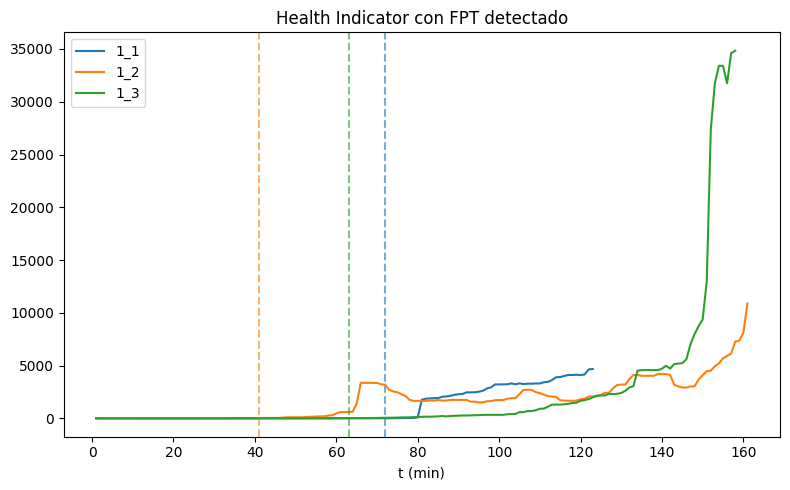

In [ ]:
print('=== Calculando Health Indicator (HI) y FPT ===')
hi_list = [health_indicator_causal(g, feat_cols) for _, g in df.groupby('bearing')]
hi_df = pd.concat(hi_list, ignore_index=True)

fpts = {}
for b, g in hi_df.groupby('bearing'):
    g = g.sort_values('t').reset_index(drop=True)
    fpts[b] = detect_fpt(g)
    print(f'  {b} → FPT en t = {fpts[b]}')

fig, ax = plt.subplots(figsize=(8, 5))
for b, g in hi_df.groupby('bearing'):
    g = g.sort_values('t')
    line, = ax.plot(g['t'], g['hi_z'], label=b)
    if fpts[b] is not None:
        ax.axvline(fpts[b], linestyle='--', alpha=0.6, color=line.get_color())
ax.legend()
ax.set_title('Health Indicator con FPT detectado')
ax.set_xlabel('t (min)')
plt.tight_layout()
plt.show()


## 4. RUL con tope y filtrado post-FPT

In [ ]:
fpt_df = pd.DataFrame({'bearing': list(fpts.keys()), 'fpt': list(fpts.values())})
df = df.merge(fpt_df, on='bearing', how='left')
df['rul_capped'] = df['rul'].clip(upper=RUL_CAP)
df_post_fpt = df[df['t'] >= df['fpt']].copy()
print('=== Filas post-FPT por rodamiento ===')
print(df_post_fpt.groupby('bearing').size())


=== Filas post-FPT por rodamiento ===
bearing
1_1     52
1_2    121
1_3     96
dtype: int64


## 5. Selección de features para el regresor de RUL

In [ ]:
def select_features(train, cols, k=12, corr_max=0.95):
    """Elige `k` features monótonas con `t` (evaluadas en cada rodamiento de
    train por separado, tomando el mínimo), descartando redundantes."""
    score = {}
    for c in cols:
        rhos = [abs(stats.spearmanr(g[c], g['t'])[0]) for _, g in train.groupby('bearing')]
        score[c] = min(rhos)
    ranked = sorted(score, key=score.get, reverse=True)
    keep = []
    for c in ranked:
        if all(abs(train[c].corr(train[k_])) < corr_max for k_ in keep):
            keep.append(c)
        if len(keep) == k:
            break
    return keep


## 6. Validación leave-one-bearing-out (Ridge vs. Random Forest)

Resultado **informativo/comparativo**: en cada fold, un rodamiento queda
totalmente fuera del entrenamiento. El modelo que finalmente se guarda
(sección siguiente) usa un enfoque distinto (híbrido), que dio mejor
desempeño auditado.

In [ ]:
print('=== Validación leave-one-bearing-out (Ridge vs. Random Forest) ===')
resultados = {}
for test_b in BEARINGS:
    train = df_post_fpt[df_post_fpt.bearing != test_b].copy()
    test = df_post_fpt[df_post_fpt.bearing == test_b].copy()
    cols = select_features(train, feat_cols, k=12)

    ridge = Ridge(alpha=1.0).fit(train[cols], train['rul_capped'])
    rf = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=0).fit(
        train[cols], train['rul_capped'])

    resultados[test_b] = {
        'n_features': len(cols),
        'MAE_ridge': mean_absolute_error(test['rul_capped'], ridge.predict(test[cols])),
        'MAE_rf': mean_absolute_error(test['rul_capped'], rf.predict(test[cols])),
    }

tabla_resultados = pd.DataFrame(resultados).T
print(tabla_resultados)


=== Validación leave-one-bearing-out (Ridge vs. Random Forest) ===
     n_features  MAE_ridge     MAE_rf
1_1        12.0  32.829126  15.452991
1_2        12.0  23.201810  27.946870
1_3        12.0  16.451290  13.432914


## 7. Modelo final (híbrido) y guardado de `model.pkl`

Se entrena con **1_1 y 1_3 completos** más el **70% inicial de 1_2**,
dejando el 30% final de `1_2` como tramo genuinamente fuera de muestra
(auditado, sin overlap de filas entre train y test).

In [ ]:
print('=== Entrenando el modelo final (híbrido, con 1_2 como unidad parcial) ===')
g_1_2 = df_post_fpt[df_post_fpt.bearing == '1_2'].sort_values('t').reset_index(drop=True)
n_cut = int(len(g_1_2) * 0.7)
train_1_2_part = g_1_2.iloc[:n_cut]
test_1_2_part = g_1_2.iloc[n_cut:]

train_final = pd.concat([
    df_post_fpt[df_post_fpt.bearing == '1_1'],
    df_post_fpt[df_post_fpt.bearing == '1_3'],
    train_1_2_part,
], ignore_index=True)

cols_finales = select_features(train_final, feat_cols, k=12)
print('  Features finales:', cols_finales)

modelo_final = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=0)
modelo_final.fit(train_final[cols_finales], train_final['rul_capped'])

mae_test_1_2 = mean_absolute_error(
    test_1_2_part['rul_capped'], modelo_final.predict(test_1_2_part[cols_finales]))
print(f'  MAE en 1_2 (tramo fuera de muestra, auditado): {mae_test_1_2:.2f} min '
      f'({mae_test_1_2 / RUL_CAP * 100:.1f}% sobre RUL_CAP={RUL_CAP})')


=== Entrenando el modelo final (híbrido, con 1_2 como unidad parcial) ===
  Features finales: ['v_band4', 'v_band5', 'v_band2', 'v_band1', 'h_band1', 'h_p2p', 'h_band2', 'v_peak', 'h_band3', 'v_bpfo_h1', 'v_bpfo_sum', 'h_bpfo_h1']
  MAE en 1_2 (tramo fuera de muestra, auditado): 6.21 min (10.3% sobre RUL_CAP=60)


In [ ]:
os.makedirs(OUTPUT_DIR, exist_ok=True)
paquete = {
    'modelo': modelo_final,
    'features': cols_finales,
    'rul_cap': RUL_CAP,
    'tipo_modelo': 'RandomForestRegressor',
    'train_bearings': ['1_1', '1_3'],
    'train_partial': {'bearing': '1_2', 't_max_train': int(train_1_2_part['t'].max())},
    'test_bearing_partial': {'bearing': '1_2', 't_min_test': int(test_1_2_part['t'].min())},
    'mae_auditado_test': round(mae_test_1_2, 2),
}
model_path = os.path.join(OUTPUT_DIR, 'model.pkl')
joblib.dump(paquete, model_path)
print(f'Modelo guardado en {model_path}')


Modelo guardado en /content/sample_data/model.pkl


## 8. Generar `datos_muestra.csv` (train/test etiquetado)

In [ ]:
train_final_copy = train_final.copy()
test_final = test_1_2_part.copy()
train_final_copy['split'] = 'train'
test_final['split'] = 'test'

n_train_muestra = min(70, len(train_final_copy))
n_test_muestra = min(30, len(test_final))
muestra = pd.concat([
    train_final_copy.sample(n_train_muestra, random_state=0),
    test_final.sample(n_test_muestra, random_state=0),
], ignore_index=True)

columnas_finales = cols_finales + ['bearing', 't', 'rul', 'rul_capped', 'split']
muestra = muestra[columnas_finales].sort_values(['split', 'bearing', 't']).reset_index(drop=True)

muestra_path = os.path.join(OUTPUT_DIR, 'datos_muestra.csv')
muestra.to_csv(muestra_path, index=False)
print(f'Muestra guardada en {muestra_path}')
print(muestra['split'].value_counts())
print(muestra['bearing'].value_counts())


Muestra guardada en /content/sample_data/datos_muestra.csv
split
train    70
test     30
Name: count, dtype: int64
bearing
1_2    54
1_3    33
1_1    13
Name: count, dtype: int64


## 9. Fin del entrenamiento

In [1]:
print('=== Entrenamiento y evaluación completos ===')
print('model.pkl y datos_muestra.csv listos para usar en notebook_final_predictor_rul.ipynb')


=== Entrenamiento y evaluación completos ===
model.pkl y datos_muestra.csv listos para usar en notebook_final_predictor_rul.ipynb
